# Generación de datos de entrenamiento

Este notebook presenta una guía rápida para generar el conjunto de datos necesario para el entrenamiento de modelos de Machine Learning mediante aprendizaje supervisado. El proceso se divide en tres etapas principales:

1. **Generación de instancias**
2. **Generación de datos**
3. **Implementación de nuevos adaptadores**

## 1. Generación de instancias

En el contexto del **CPMP**, definimos una instancia a partir de tres parámetros clave:

- **S (Stacks):** Número de *stacks* (pilas) disponibles.
- **H (Height):** Altura máxima permitida para cada *stack*.
- **N (Nodes/Containers):** Número total de contenedores.

Para crear estas configuraciones, el framework utiliza **Generadores** (*Generators*). La elección del generador es crítica, ya que determina el nivel de "ruido" y la dificultad de los datos con los que aprenderá el modelo.

### Tipos de Generators disponibles:

- **FullRandom**: Genera *layouts* con una distribución de contenedores completamente aleatoria.
- **RandomMoves**: Parte de un *layout* ya ordenado y aplica $r$ movimientos aleatorios para desordenarlo de forma controlada.
- **BadPlacedUniform**: Genera instancias balanceadas por dificultad, donde esta se mide en función del número de contenedores mal ubicados.
- **UniformCost**: Genera instancias balanceadas por dificultad. En este caso, la métrica corresponde a una aproximación estadística del número de movimientos que le tomaría a FRG resolver cada instancia.
- **UniformEmpirical**: Genera instancias balanceadas por dificultad. A diferencia de `UniformCost`, el balanceo es exacto: el costo real se calcula resolviendo directamente cada instancia mediante un *solver* específico. Posee dos variantes: 
    - **FRGUniformEmpirical**: Utiliza FRG como solver para resolver el problema.
    - **ModelUniformEmpirical**: Utiliza el modelo como agente *greedy* para resolver el problema. 

### Ejecución de la generación

Para ejecutar el proceso, emplearemos la función `generate_instances`. En ella, especificaremos el `basename` (directorio de salida), el `generator` previamente configurado y el parámetro `amount` (la cantidad total de instancias que deseamos obtener).

In [14]:
from instances import generate_instances
from instances.generators import FRGUniformEmpiricalGenerator

ue_generator = FRGUniformEmpiricalGenerator(H=7, S=5, seed=42)
generate_instances(basename="ejemplo_ue", generator=ue_generator, amount=5000)

Iniciando Pool con 12 workers paralelos...
Iniciando fase de Burn-in (Descubrimiento)...
[Burn-in] k=1    | Promedio=1.00 | U_actual=1
[Burn-in] k=2    | Promedio=1.25 | U_actual=1
[Burn-in] k=3    | Promedio=1.76 | U_actual=2
[Burn-in] k=5    | Promedio=2.81 | U_actual=3
[Burn-in] k=8    | Promedio=3.68 | U_actual=4 | Crec. Prom=1.50
[Burn-in] k=13   | Promedio=6.06 | U_actual=6 | Crec. Prom=2.42
[Burn-in] k=21   | Promedio=7.40 | U_actual=7 | Crec. Prom=2.90
[Burn-in] k=34   | Promedio=11.74 | U_actual=12 | Crec. Prom=4.72
[Burn-in] k=55   | Promedio=14.64 | U_actual=15 | Crec. Prom=5.20
[Burn-in] k=89   | Promedio=18.68 | U_actual=19 | Crec. Prom=7.62
[Burn-in] k=144  | Promedio=21.69 | U_actual=22 | Crec. Prom=6.60
[Burn-in] k=233  | Promedio=25.90 | U_actual=26 | Crec. Prom=7.45
[Burn-in] k=377  | Promedio=28.15 | U_actual=28 | Crec. Prom=6.57
[Burn-in] k=610  | Promedio=30.16 | U_actual=30 | Crec. Prom=6.38
[Burn-in] k=987  | Promedio=30.63 | U_actual=31 | Crec. Prom=3.75
[Burn-i

## 2. Generación de datos

En esta etapa, transformamos las instancias generadas en conocimiento útil para el modelo. El proceso consiste en resolver dichas instancias mediante un **solver** para obtener sus soluciones óptimas y, a partir de estas, extraer pares de entrada-salida (*features* y *labels*).

Para flexibilizar la forma en que el modelo "observa" el problema, utilizaremos diferentes **adaptadores** (*adapters*).

### Input Adapters

Estos componentes definen la representación del *layout* que el modelo recibirá como entrada.

#### LayoutAdapter (Matriz de contenedores)

Representan el estado individual de los contenedores dentro de las pilas. Disponemos de tres versiones:

- **V1:** Enfocada en el orden lógico. Incluye el *group value* y dos variables binarias (`valid_top` y `valid_bottom`) que indican si un contenedor respeta el orden respecto a sus vecinos superior e inferior.
- **V2:** Enfocada en la estructura espacial. Incorpora el *group value* y métricas de posición: `depth` (profundidad dentro del *stack* actual) y `pos` (posición relativa a la altura máxima $H_{max}$).
- **V3:** Una representación integral que combina todas las *features* de las versiones V1 y V2.

#### StackFeaturesAdapter (Atributos del stack)

Si la arquitectura del modelo lo requiere, podemos extraer métricas globales por cada pila para complementar la visión espacial. Actualmente implementamos:

- **V1:** Proporciona una visión general del estado del *stack* mediante `is_sorted` (booleano), `height_ratio` ($H/H_{max}$) y `sorted_ratio` (proporción de la base que ya se encuentra correctamente ordenada).

> 💡 **Tip:** Para combinar ambas perspectivas (contenedores y *stacks*), utilizaremos el **EnrichedLayoutAdapter**. Este adaptador integra un objeto de cada clase para generar un *input* mucho más robusto.

### Output Adapters

Estos adaptadores definen el objetivo de predicción del modelo (*target*):

- **ActionAdapter:** El modelo aprende a predecir la siguiente **acción** óptima (el movimiento de un contenedor desde un *stack* de origen hacia uno de destino).
- **CostAdapter:** El modelo estima el **costo** total, que equivale al número de movimientos restantes necesarios para resolver el *layout*.

### Función generadora y procesamiento

Para producir el *dataset* de entrenamiento bajo un esquema de aprendizaje supervisado, utilizaremos la función `generate_data_sl`. En el siguiente bloque de código, configuramos los adaptadores, el *solver* y definimos el nivel de paralelismo mediante el parámetro `num_workers`.

In [15]:
from generation.data import generate_data_sl
from generation.adapters.input import EnrichedLayoutAdapter, Layout4DAdapterV2
from generation.adapters.input.stack_features import StackFeaturesAdapterV1
from generation.adapters.output import ActionAdapter
from solvers import FRGSolver

# Configuración del proceso
folder = "ejemplo_ue"
H = 7
max_steps = 50
num_workers = None
output_prefix = None

# Definimos la combinación de adaptadores
input_adapter_config = (EnrichedLayoutAdapter, Layout4DAdapterV2, StackFeaturesAdapterV1, 10, 8)
output_adapter_config = (ActionAdapter, )

# Configuración del solver
solver_config = (FRGSolver, )

# Ejecutamos la generación de datos transformando las soluciones del solver
generate_data_sl(
    folder, 
    H, 
    max_steps, 
    input_adapter_config, 
    output_adapter_config, 
    solver_config, 
    num_workers, 
    output_prefix
)

Iniciando generación de datos para 5000 archivos con 12 workers...
Progreso: 500/5000 archivos procesados.
Progreso: 1000/5000 archivos procesados.
Progreso: 1500/5000 archivos procesados.
Progreso: 2000/5000 archivos procesados.
Progreso: 2500/5000 archivos procesados.
Progreso: 3000/5000 archivos procesados.
Progreso: 3500/5000 archivos procesados.
Progreso: 4000/5000 archivos procesados.
Progreso: 4500/5000 archivos procesados.
Progreso: 5000/5000 archivos procesados.
Generación de datos finalizada con éxito.
Datos guardados en: /home/oscar/Escritorio/CPMP-Framework/data/ejemplo_ue.data (Tamaño 5000)


### Creación de datasets específicos

Una vez generados los archivos de datos base, utilizaremos la función `generate_dataset` para filtrar, limitar o balancear la información que finalmente alimentará al modelo.

Para generar un *dataset* balanceado podemos utilizar el parámetro `balance_method`. Se dispone de dos criterios:

- **Por costo** (`'cost'`).
- **Por archivo de origen** (`'file'`).

In [16]:
from preprocessing.dataset import generate_dataset
from analysis import plot_counts

data_files = ["ejemplo_ue.data"]
max_size = 2000       # Limitamos a 2000 muestras totales
min_cost = 5          # Solo instancias que requieran al menos 5 movimientos
max_cost = 40         # Y como máximo 40
balance_method = 'cost'
output_name = "dataset_ejemplo_ue.data"

generate_dataset(data_files, output_name, min_cost, max_cost, max_size, balance_method)

Dataset generado exitosamente en: /home/oscar/Escritorio/CPMP-Framework/data/dataset_ejemplo_ue.data (Tamaño 2000)


Adicionalmente, podemos visualizar el número de pasos que requirió el _solver_ para resolver cada instancia. Dado que configuramos `balance_method = 'cost'`, la gráfica debería mostrar una distribución perfectamente uniforme en relación con el costo.

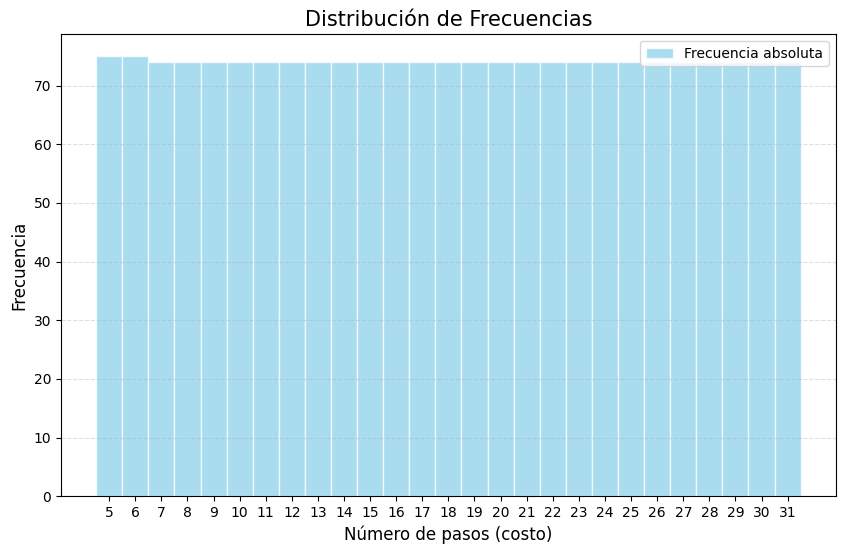

In [19]:
# Verificación de la distribución resultante
plot_counts("dataset_ejemplo_ue.data")

## 3. Implementación de nuevos adaptadores

Si estamos experimentando con nuevas arquitecturas, es probable que necesitemos definir formatos de entrada personalizados. Por ejemplo, supongamos que queremos representar cada contenedor con su valor de grupo normalizado c y una nueva _feature_ correspondiente a log(c).

Para ello, implementaremos la clase `CustomLayoutAdapter` heredando de `LayoutAdapter`. El método principal a definir es `input_2_vec`, el cual transforma un objeto `Layout` en un tensor numérico.

Esta función gestiona dos aspectos críticos:

1.  **Extracción de features:** La lógica de cálculo para cada celda.
2.  **Padding:** El uso de Smax​ y Hmax​ para asegurar que el modelo reciba siempre tensores de tamaño fijo, independientemente de la instancia.

In [8]:
import numpy as np
from generation.adapters.input.layout.layout_adapter import LayoutAdapter

class CustomLayoutAdapter(LayoutAdapter):
    def __init__(self, S_max, H_max):
        super().__init__(S_max, H_max)

    def input_2_vec(self, layout, H):
        stacks_matrix = []
        
        # Obtenemos el valor máximo para normalizar
        all_vals = [c for s in layout.stacks for c in s]
        max_val = max(all_vals) if all_vals else 1

        # 1. Procesamiento y Padding de ALTURA (H_max)
        for i in range(len(layout.stacks)):
            stack = []
            for j in range(len(layout.stacks[i])):
                val = layout.stacks[i][j]
                normalized_c = val / max_val
                # Nueva feature sugerida: log(c) (usamos log1p para evitar log(0))
                log_c = np.log1p(val) 
                
                # Cada celda tendrá 2 valores: [c_norm, log_c]
                stack.append([normalized_c, log_c])
            
            # Aplicamos padding a la pila actual rellenando con -1.0
            padding_size = self.H_max - len(stack)
            padded_stack = stack[:self.H_max] + [[-1.0, -1.0]] * max(0, padding_size)
            stacks_matrix.append(padded_stack)

        # 2. Padding de STACKS (S_max)
        num_current_stacks = len(stacks_matrix)
        stacks_to_add = self.S_max - num_current_stacks
        
        if stacks_to_add > 0:
            # Rellenamos con stacks vacíos de tamaño (H_max, 2)
            empty_stack = [[-1.0, -1.0]] * self.H_max
            for _ in range(stacks_to_add):
                stacks_matrix.append(empty_stack)
        else:
            stacks_matrix = stacks_matrix[:self.S_max]

        # El resultado final tendrá un shape de (S_max, H_max, 2)
        return (np.array(stacks_matrix, dtype=np.float32), )

### Uso del adaptador personalizado

Una vez definida la clase, la integramos en el flujo de generación como cualquier otro adaptador.

In [9]:
from generation.data import generate_data_sl
from generation.adapters.output import ActionAdapter
from solvers import FRGSolver

# Configuramos la generación usando nuestro nuevo adaptador
input_adapter_config = (CustomLayoutAdapter, 10, 8)
output_adapter_config = (ActionAdapter, )
solver_config = (FRGSolver, )

generate_data_sl(
    folder="ejemplo_fr", 
    H=7, 
    max_steps=50, 
    input_adapter_config=input_adapter_config, 
    output_adapter_config=output_adapter_config, 
    solver_config=solver_config,
    num_workers=12, 
    output_name_prefix="custom"
)

Datos guardados en: /home/oscar/Escritorio/CPMP-Framework/data/custom_ejemplo_fr.data (Tamaño 100)


### Verificación de los datos

Para asegurar que las _features_ se calcularon correctamente, podemos cargar una muestra del archivo generado y visualizar el contenido de una pila.

In [10]:
from preprocessing.dataset import load_data

# Cargamos el archivo para inspeccionar la estructura
data = load_data("custom_ejemplo_fr.data")
idx = 0

print("Representación de una pila (Stack 0):")
print("Format: [c_norm, log(c)]")
# Mostramos la primera pila del primer ejemplo
print(data['input/S'][idx][0])

Representación de una pila (Stack 0):
Format: [c_norm, log(c)]
[[ 0.76       2.9957323]
 [ 0.44       2.4849067]
 [ 0.08       1.0986123]
 [ 0.16       1.609438 ]
 [ 0.48       2.5649493]
 [ 0.84       3.0910425]
 [-1.        -1.       ]
 [-1.        -1.       ]]
